In [202]:
# load libraries
import pandas as pd
import numpy as np
# train test split
from sklearn.model_selection import train_test_split
# GridSearchCV - hyperparameter tuning
from sklearn.model_selection import GridSearchCV
# models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost
# metrics
from sklearn.metrics import accuracy_score, log_loss
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
# data visualization
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import shap


In [203]:
# Setting random seed for reproducibility
np.random.seed(42)

Import Data

In [204]:
df_raw_data = pd.read_csv('../02_src/uci_diabetes.csv')
df_raw_data.head()

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive


In [205]:
# filtering by gender - female
df = df_raw_data.loc[df_raw_data['Gender'] == 'Female']

Data Cleaning

In [206]:
# Gender column is not needed since all members are the same and we are not including gender as a predictor
df = df.drop(columns=['Gender'])

# Binary encoding
binary_map = {"Yes": 1, "No": 0}
#gender_map = {"Male": 0, "Female": 1}
class_map = {"Negative": 0, "Positive": 1}

# dropping demographic data and class (y variable)
symptom_cols = df.columns.drop(["Age", "class"])

df[symptom_cols] = df[symptom_cols].replace(binary_map)
#df["Gender"] = df["Gender"].replace(gender_map)
df["class"] = df["class"].replace(class_map)


C:\Users\shafe\AppData\Local\Temp\ipykernel_32940\4158227504.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[symptom_cols] = df[symptom_cols].replace(binary_map)
C:\Users\shafe\AppData\Local\Temp\ipykernel_32940\4158227504.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["class"] = df["class"].replace(class_map)


In [207]:

df['AgeGroup'] = pd.cut(df['Age'],
                        bins=[0,30,45,60,100],
                        labels=['<30','30–44','45–59','60+'])

# for these algorithms, we will not need the Age as an int
df = df.drop(columns=['Age'])

In [208]:
# Perform one-hot encoding on the 'AgeGroup' column
#  drop_first=True to avoid multicollinearity
df_encoded = pd.get_dummies(df, columns=['AgeGroup'], prefix='AgeGroup',  drop_first=True)

print(df_encoded.columns)

Index(['Polyuria', 'Polydipsia', 'sudden weight loss', 'weakness',
       'Polyphagia', 'Genital thrush', 'visual blurring', 'Itching',
       'Irritability', 'delayed healing', 'partial paresis',
       'muscle stiffness', 'Alopecia', 'Obesity', 'class', 'AgeGroup_30–44',
       'AgeGroup_45–59', 'AgeGroup_60+'],
      dtype='object')


In [209]:
# target (y) dataset
target = df['class']
target

39     1
40     1
41     1
42     1
43     1
      ..
514    1
515    1
516    1
517    1
518    0
Name: class, Length: 192, dtype: int64

In [210]:
# predictors dataset
df_data = df_encoded.drop(columns=['class'])
df_data

,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,AgeGroup_30–44,AgeGroup_45–59,AgeGroup_60+
39,1,0,1,1,1,0,0,0,0,1,0,0,0,0,False,False,False
40,0,1,1,0,1,1,1,1,1,1,0,1,0,0,False,True,False
41,1,1,1,0,1,0,0,0,0,1,1,0,0,0,False,True,False
42,0,1,0,1,1,0,1,1,1,1,1,1,0,0,False,True,False
43,1,1,1,1,1,0,0,1,0,1,1,1,0,0,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
514,1,1,1,1,1,0,0,0,0,0,1,0,0,0,False,True,False
515,1,1,1,0,1,0,0,1,0,1,1,0,0,0,True,False,False
516,1,1,1,1,1,0,0,1,1,1,1,0,0,0,False,True,False
517,1,1,1,1,1,0,1,0,0,0,1,1,0,1,False,True,False


X and Y

In [211]:
X = df_data
y = target

In [212]:
# Train/Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle= True, stratify = y,
) #

Subroutine that will be re-used for evaluation

In [213]:
# subroutine for evaluation
def evaluation(model, X_test, y_test):
    # testing
    y_pred = model.predict(X_test)

    print(classification_report(y_pred, y_test))

    # Evaluation
    # Get the default accuracy score
    accuracy = model.score(X_test, y_test)
    print(f"Accuracy Score: {accuracy}")

    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                display_labels=model.classes_)
    disp.plot()
    plt.show()

    # Calculate the log loss
    y_pred_proba = model.predict_proba(X_test)
    loss = log_loss(y_test, y_pred_proba)

    print(f"Log Loss: {loss}")

Testing with Logistic Regression

In [214]:
# Initialize
model = LogisticRegression()
# Train Model
model.fit(X_train, y_train) 


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

              precision    recall  f1-score   support

           0       0.50      1.00      0.67         2
           1       1.00      0.95      0.97        37

    accuracy                           0.95        39
   macro avg       0.75      0.97      0.82        39
weighted avg       0.97      0.95      0.96        39

Accuracy Score: 0.9487179487179487


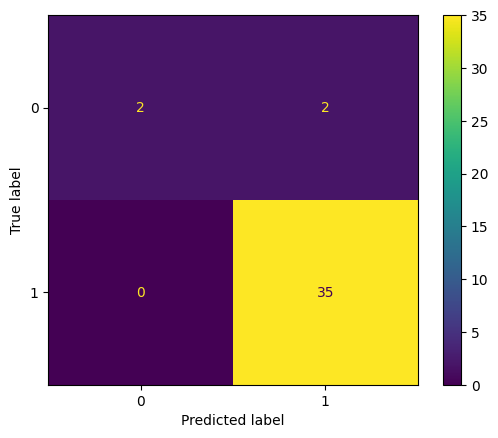

Log Loss: 0.10739412776102306


In [215]:
# Predict and Evaluate
evaluation(model, X_test, y_test)

Decision Tree Classifier

              precision    recall  f1-score   support

           0       0.50      1.00      0.67         2
           1       1.00      0.95      0.97        37

    accuracy                           0.95        39
   macro avg       0.75      0.97      0.82        39
weighted avg       0.97      0.95      0.96        39

Accuracy Score: 0.9487179487179487


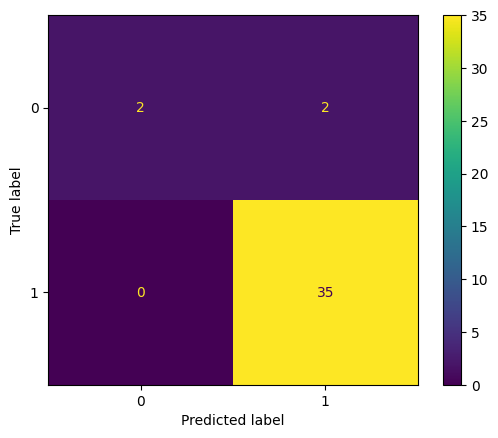

Log Loss: 0.08825690708160047


In [216]:
# Initialize
model_dtc = DecisionTreeClassifier()
# Train model
model_dtc.fit(X_train, y_train)

# Predict and Evaluate
evaluation(model_dtc, X_test, y_test)

Random Forest Classifier

In [217]:
# Initialize the Random Forest Classifier
model_rfc = RandomForestClassifier(n_estimators=100, class_weight='balanced')

# Train the model
model_rfc.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

              precision    recall  f1-score   support

           0       1.00      0.80      0.89         5
           1       0.97      1.00      0.99        34

    accuracy                           0.97        39
   macro avg       0.99      0.90      0.94        39
weighted avg       0.98      0.97      0.97        39

Accuracy Score: 0.9743589743589743


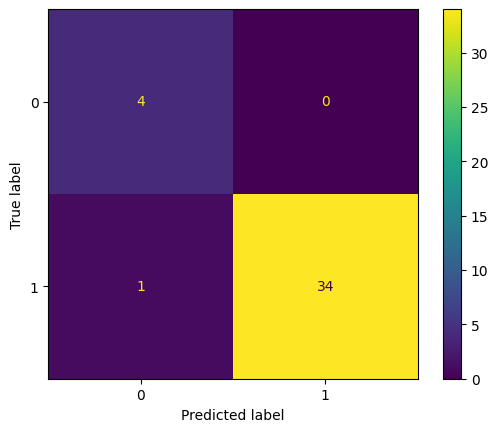

Log Loss: 0.07563985742430877


In [218]:
evaluation(model_rfc, X_test, y_test)

Log loss report seems most promising for random tree classifier so will perform hyperparameter tuning and further evaluation with random forest algorithm

In [219]:
# source https://www.geeksforgeeks.org/machine-learning/random-forest-hyperparameter-tuning-in-python/
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

# mplement a grid search using GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(RandomForestClassifier(class_weight='balanced'), param_grid=param_grid, cv=10)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Estimator:", grid_search.best_estimator_)

Best Parameters: {'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Estimator: RandomForestClassifier(class_weight='balanced')


              precision    recall  f1-score   support

           0       1.00      0.80      0.89         5
           1       0.97      1.00      0.99        34

    accuracy                           0.97        39
   macro avg       0.99      0.90      0.94        39
weighted avg       0.98      0.97      0.97        39

Accuracy Score: 0.9743589743589743


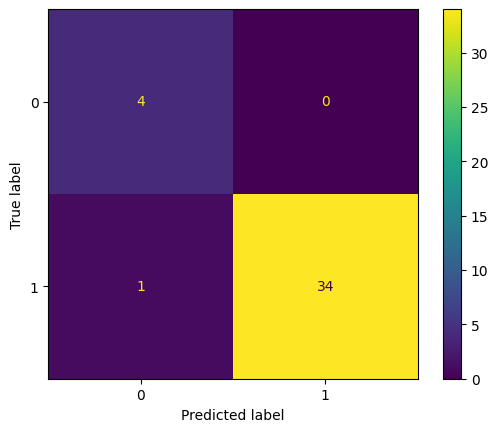

Log Loss: 0.07197945100172598


In [220]:
model_grid = RandomForestClassifier(class_weight='balanced')
model_grid.fit(X_train, y_train)

# testing and evaluation
evaluation(model_grid, X_test, y_test)

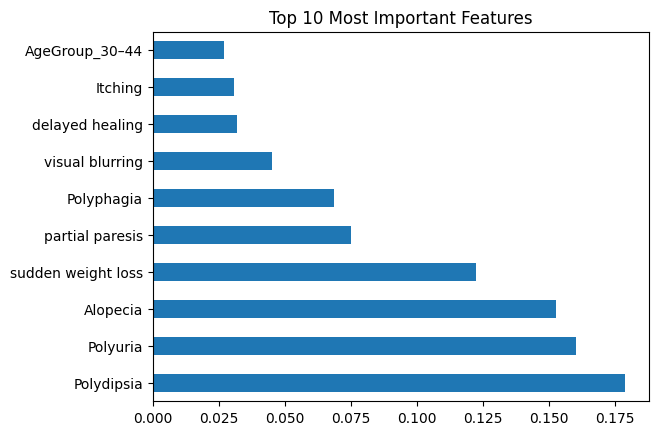

In [221]:
# Create a Series with feature importances
importances = pd.Series(model_grid.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh') # top 10
plt.title("Top 10 Most Important Features")
plt.show()

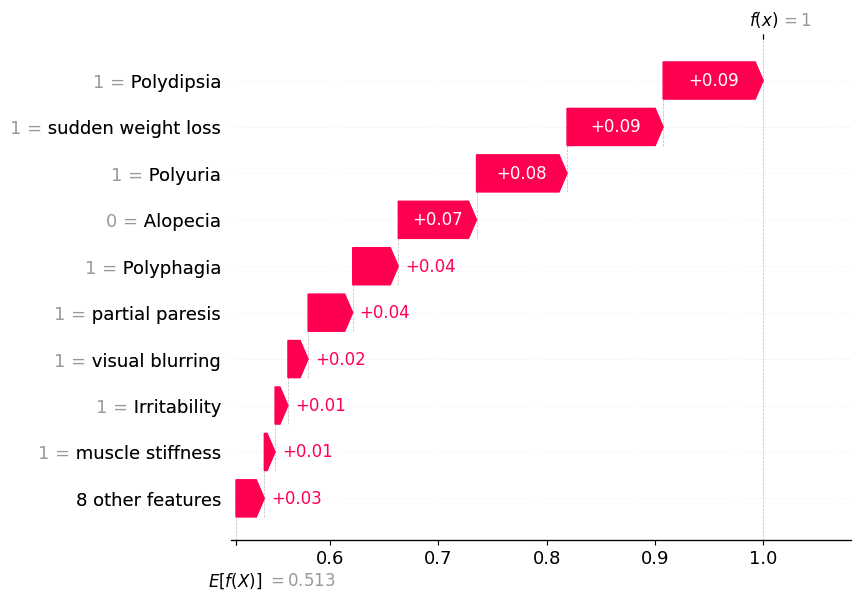

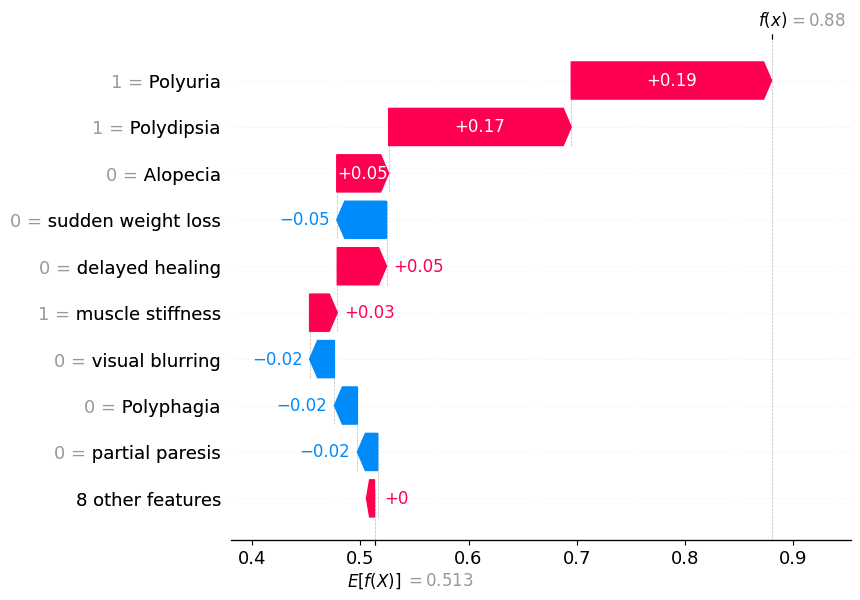

In [222]:
# SHAP
# TreeExplainer is highly optimized for Random Forests
explainer = shap.TreeExplainer(model_rfc)
shap_values = explainer(X_test) # Calculate SHAP values for the test set

# Local Explanation: Waterfall Plot
# Shows why the model made a specific prediction (e.g., for the first test row)
# Note: For classification, we specify index [:, :, 1] for the 'Positive' class
shap.plots.waterfall(shap_values[0, :, 1])
shap.plots.waterfall(shap_values[1, :, 1])

C:\Users\shafe\AppData\Local\Temp\ipykernel_32940\2344957999.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, 1], X_test)


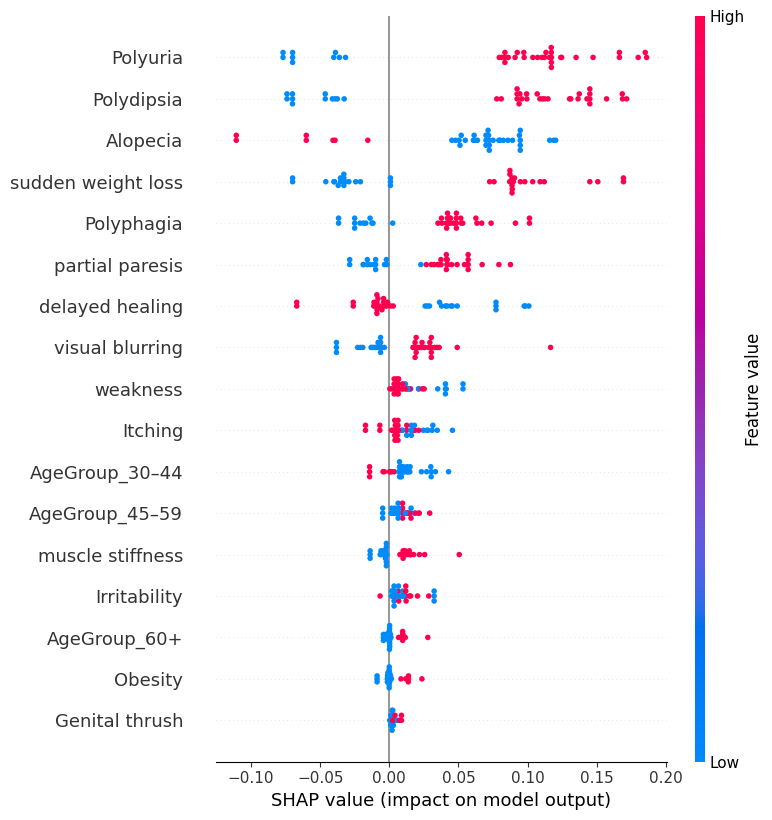

In [223]:
shap.summary_plot(shap_values[:, :, 1], X_test)

              precision    recall  f1-score   support

           0       0.50      1.00      0.67         2
           1       1.00      0.95      0.97        37

    accuracy                           0.95        39
   macro avg       0.75      0.97      0.82        39
weighted avg       0.97      0.95      0.96        39

Accuracy Score: 0.9487179487179487


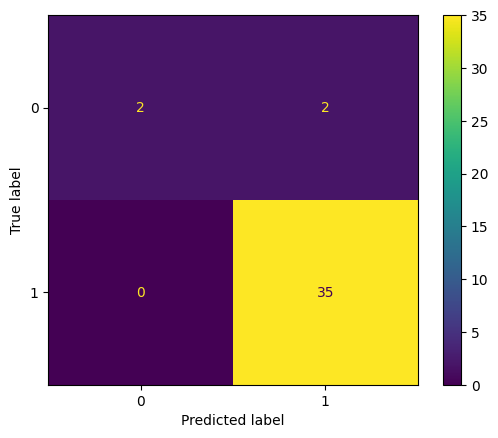

Log Loss: 0.08197344825130935


In [224]:
# Train a model
model_xgb = xgboost.XGBClassifier()
model_xgb.fit(X_train, y_train)
evaluation(model_xgb, X_test, y_test)

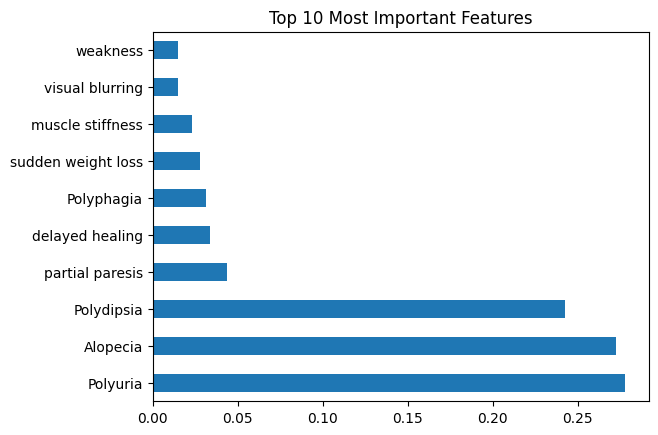

In [225]:
# Create a Series with feature importances
importances = pd.Series(model_xgb.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh') # top 10
plt.title("Top 10 Most Important Features")
plt.show()

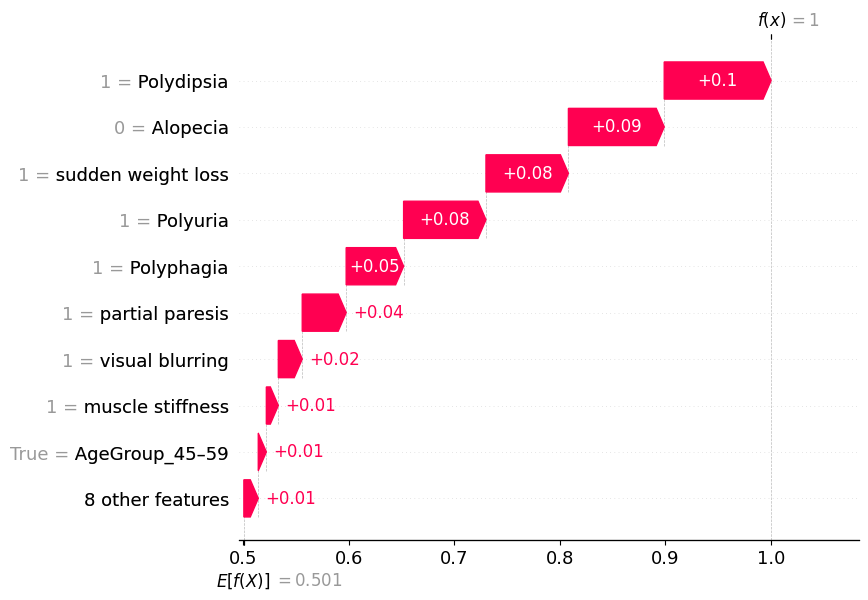

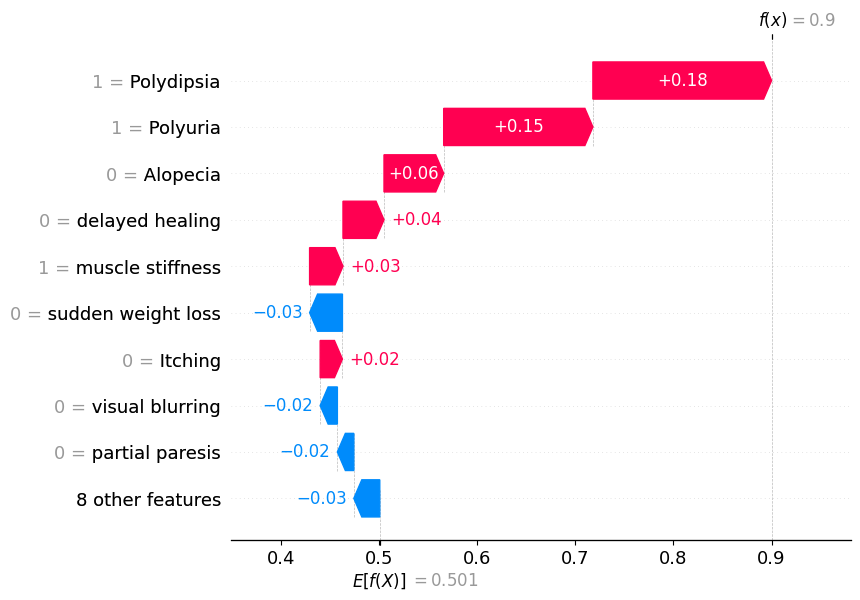

In [226]:
# SHAP
# TreeExplainer is highly optimized for Random Forests
explainer = shap.TreeExplainer(model_grid)
shap_values = explainer(X_test) # Calculate SHAP values for the test set

# Local Explanation: Waterfall Plot
# Shows why the model made a specific prediction (e.g., for the first test row)
# Note: For classification, we specify index [:, :, 1] for the 'Positive' class
shap.plots.waterfall(shap_values[0, :, 1])
shap.plots.waterfall(shap_values[1, :, 1])

C:\Users\shafe\AppData\Local\Temp\ipykernel_32940\2344957999.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, 1], X_test)


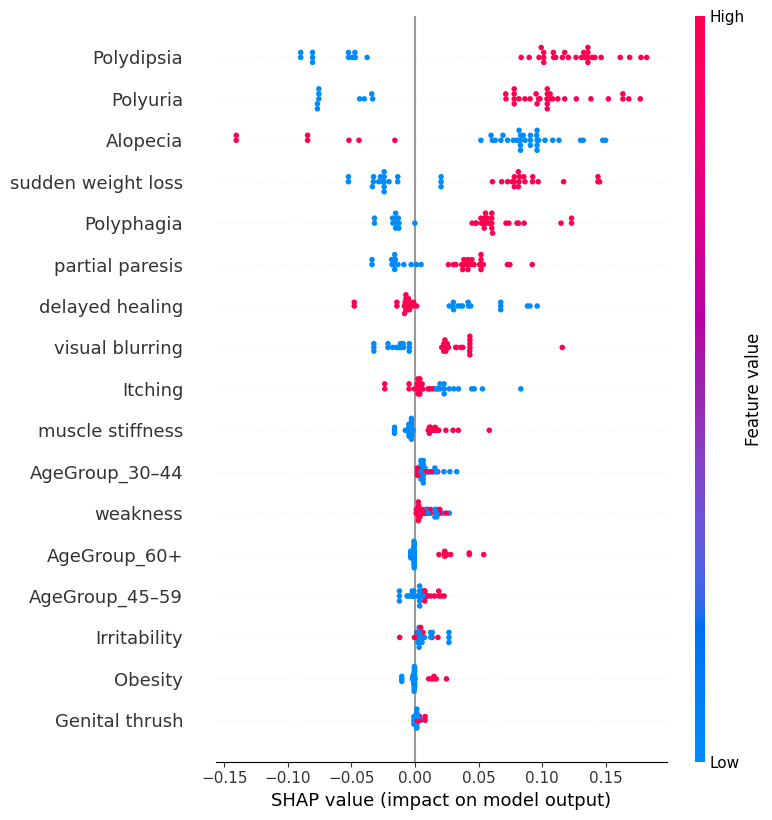

In [227]:
shap.summary_plot(shap_values[:, :, 1], X_test)